The purpose of this file is to perform analysis on test_31-test60 (sample duration variance)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [9]:
durations = [90 + 30*i for i in range(18)]
n_sheets = 3

data = []
for duration in durations:
   sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets)])
   # if duration > 300:
   #    sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets+1)])
   # else:
   #    sheet = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="General") for i in range(0,n_sheets)])
   data.append(np.array([sheet[f"Channel {i}"] for i in range(3)]))
   print(f"There are {len(sheet)/5:3.0f} data points for {duration:3} s")
# There was an issue with test_39, so we can't convert to a numpy array (inhomogenous shape)
# data = np.array(data)
print(len(data))
for i in range(len(data)): print(len(data[i]),end=', ')
print()
for i in range(len(data[0])): print(len(data[0][i]),end=', ')
print()
for i in range(len(data[1])): print(len(data[1][i]),end=', ')

There are 180 data points for  90 s
There are 142 data points for 120 s
There are 114 data points for 150 s
There are  96 data points for 180 s
There are  84 data points for 210 s
There are  73 data points for 240 s
There are  63 data points for 270 s
There are  58 data points for 300 s
There are  52 data points for 330 s
There are  49 data points for 360 s
There are  46 data points for 390 s
There are  43 data points for 420 s
There are  40 data points for 450 s
There are  37 data points for 480 s
There are  34 data points for 510 s
There are  34 data points for 540 s
There are  31 data points for 570 s
There are  30 data points for 600 s
18
3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 
900, 900, 900, 
710, 710, 710, 

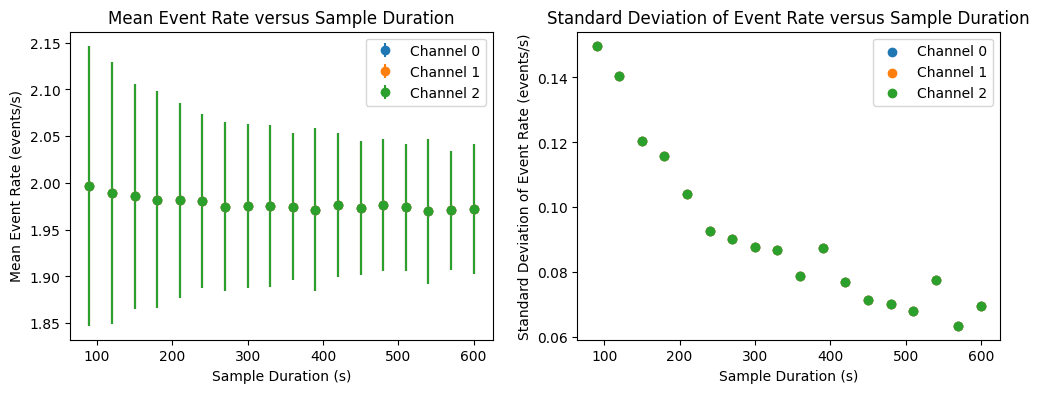

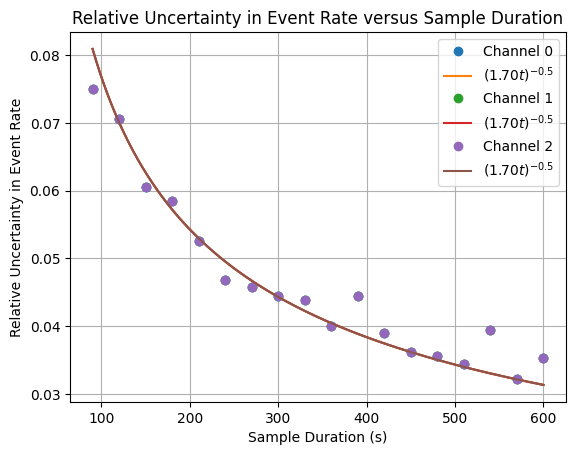

In [10]:
def get_mean_and_std(data, ch, idx, durations, pm = True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx::5]
      # print(subset)
      # print()
      if pm:
         subset = np.array([np.array(er.split(" ± "),dtype=np.float64)[0] for er in subset])
      # print(subset)
      # print()
      output.append([np.mean(subset),np.std(subset)])
   return output

def f(x,m,b):
   return m * x + b

def g(x,b):
   return 1 / np.sqrt(x * b)

fig, axs = plt.subplots(1,2,figsize=(12,4))
axs[1].set_title("Standard Deviation of Event Rate versus Sample Duration")
axs[1].set_xlabel("Sample Duration (s)")
axs[1].set_ylabel("Standard Deviation of Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[1].scatter(durations,[pair[1] for pair in event_rate],label=f"Channel {ch}")
axs[1].legend()

axs[0].set_title("Mean Event Rate versus Sample Duration")
axs[0].set_xlabel("Sample Duration (s)")
axs[0].set_ylabel("Mean Event Rate (events/s)")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   axs[0].errorbar(durations,[pair[0] for pair in event_rate],yerr=[pair[1] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
axs[0].legend()
plt.show()

x = np.linspace(np.min(durations),np.max(durations),1000)
plt.title("Relative Uncertainty in Event Rate versus Sample Duration")
plt.xlabel("Sample Duration (s)")
plt.ylabel("Relative Uncertainty in Event Rate")
for ch in range(3):
   event_rate = get_mean_and_std(data,ch,3,durations)
   popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in event_rate],p0=[1.99])
   plt.plot(durations,[pair[1]/pair[0] for pair in event_rate],marker='o',linestyle='',label=f"Channel {ch}")
   plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$")
plt.grid()
plt.legend()
plt.show()

In [11]:
langaus_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
   # if duration > 300:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets+1)])
   # else:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Langauss Height") for i in range(0,n_sheets)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['landau_x_mpv'], ch['landau_xi'], ch['gauss_sigma'], ch['0.10% Threshold']])
      dur_data.append(ch_stats)
   langaus_data.append(dur_data)

print(len(langaus_data))
print(len(langaus_data[0]))
print(len(langaus_data[0][0]))
print(len(langaus_data[0][0][0]))
print(langaus_data[0][0][0])

18
4
5
180
[2.14362056 0.96591369 2.74281234 2.7377068  1.09204696 4.93627483
 3.79232272 4.62069414 2.27697823 3.25182229 2.4705998  1.86063166
 3.39749188 4.88535391 4.30363806 4.42854617 2.55227146 3.65882074
 2.44932944 3.33542916 3.44076863 4.06499205 4.96063146 1.53978724
 2.72417229 1.4990181  2.05829595 3.13864461 1.66054373 2.74933646
 3.92856198 3.9230046  2.92267427 3.22645136 1.15696951 0.71577302
 0.98004073 2.27987629 2.33235737 2.71334798 2.03152749 2.38868109
 2.2898431  2.53003618 1.99729844 1.5093921  1.79856849 2.91903244
 3.64989291 1.65428743 2.29429692 2.60983118 4.89630538 2.19921531
 1.24083489 1.65814415 2.58863317 3.30201252 2.6327281  3.30031606
 2.54054769 1.86919021 3.26364368 3.91132811 2.29885097 2.22236442
 1.43675514 7.70237797 2.82408679 1.06623595 2.58520587 3.36955361
 2.9414041  4.32941349 4.5349     6.43025797 1.79477533 1.25513332
 3.13339786 1.91825917 3.64658881 3.72545364 3.54339585 1.58934991
 2.35387795 1.44100357 2.63196933 1.83549399 2.4067

Data in subset: [2.14362056 0.96591369 2.74281234 2.7377068  1.09204696 4.93627483
 3.79232272 4.62069414 2.27697823 3.25182229 2.4705998  1.86063166
 3.39749188 4.88535391 4.30363806 4.42854617 2.55227146 3.65882074
 2.44932944 3.33542916 3.44076863 4.06499205 4.96063146 1.53978724
 2.72417229 1.4990181  2.05829595 3.13864461 1.66054373 2.74933646
 3.92856198 3.9230046  2.92267427 3.22645136 1.15696951 0.71577302
 0.98004073 2.27987629 2.33235737 2.71334798 2.03152749 2.38868109
 2.2898431  2.53003618 1.99729844 1.5093921  1.79856849 2.91903244
 3.64989291 1.65428743 2.29429692 2.60983118 4.89630538 2.19921531
 1.24083489 1.65814415 2.58863317 3.30201252 2.6327281  3.30031606
 2.54054769 1.86919021 3.26364368 3.91132811 2.29885097 2.22236442
 1.43675514 7.70237797 2.82408679 1.06623595 2.58520587 3.36955361
 2.9414041  4.32941349 4.5349     6.43025797 1.79477533 1.25513332
 3.13339786 1.91825917 3.64658881 3.72545364 3.54339585 1.58934991
 2.35387795 1.44100357 2.63196933 1.83549399 2

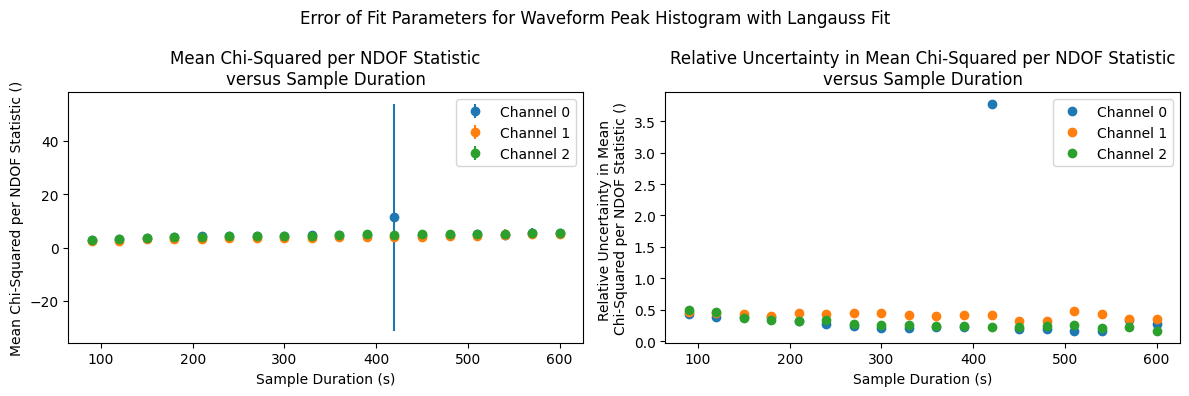

Data in subset: [ 94.77631502  79.05068647  95.81330772  84.90305019  94.70202458
  91.51060936  87.9613611   88.96057376  94.75330976  90.60371057
  95.23721699  93.35133245 100.79125205  91.51778459  88.50704808
  91.30688183  92.53993117  94.90491762  94.12645977  99.27929824
  81.33254421  91.0467237   81.88281004  83.32204599  93.27025421
  83.96837806 103.22430736  92.42305403  85.37309258  89.30861305
  89.68516319  84.92713291 100.76242964  89.69530944  78.22704377
  69.66575822  80.45894647  92.85982835  84.51013204  88.22229609
  88.48936676 100.54101362  99.34546393  99.46164779  82.46266938
  95.38307524  99.00186093  98.91751583  98.91312631  93.25542325
  93.36196321  94.5607512   94.39341245  86.78807312  91.92841822
  75.04912852  93.06843068  92.77670098  85.9689306   89.9159368
  86.42894764  97.31613345  97.78764762  90.14183921  84.78408541
  90.31252998  89.94247597  91.36174786  86.03290969  69.56116894
  89.51150731  94.45275436  77.8419139   98.70265198  83.2177

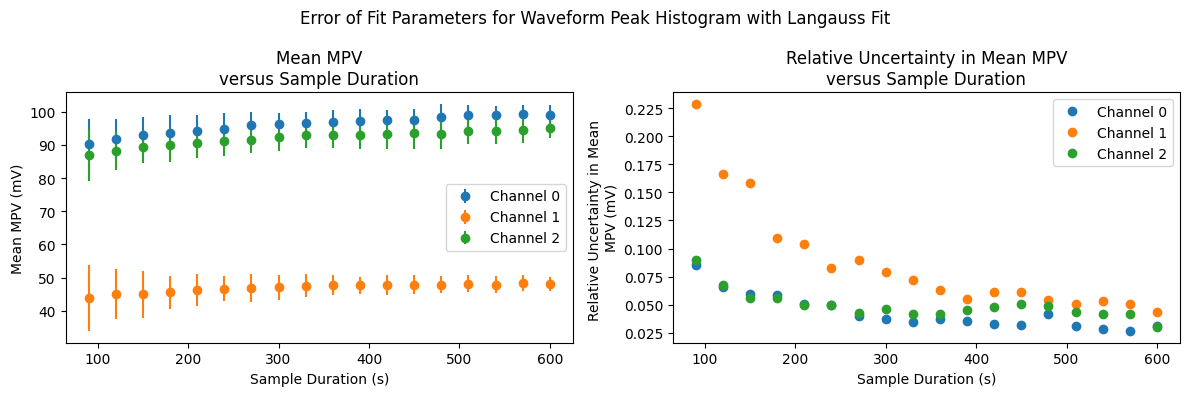

Data in subset: [ 9.1534075   7.4900134   7.5771416   9.7022955   7.71096542  8.26485752
 10.20264172  7.56505454 10.01364831  9.32226219  8.49877315  7.94193755
  7.81998742  7.41187495 10.7779742   8.3891077   5.56890979 13.64803882
  9.64068064  5.03579876  4.82177076  9.64990843 12.19590297  4.60461381
  6.96150238  5.21425333  4.95163792  7.9960903   4.41580488 11.7154845
  6.38535073  7.19474984  3.73195058  3.79741251  3.44886253  8.82865104
 10.04183664  7.01032612  8.00973093  7.04271804  4.49121923  7.39841397
  5.55592481  4.25175824  6.78047242  9.00710085 10.89574858  5.97451634
  8.6347001   8.99335916  7.78598419  9.58610789  6.89761566  8.91601046
  7.46644022  7.26106638  9.83355642  6.35125135  9.1303027   9.37354799
  4.84818346  8.34568978  9.04926981  4.76473763  6.28423317 11.36181235
  7.61131569  4.50174644  9.67328169  4.78648718  6.54782314 10.64675894
  7.84569353  6.08358498  9.22182405 11.38653444  4.42523734  8.60289945
  7.24801957  9.07936216  8.38819763

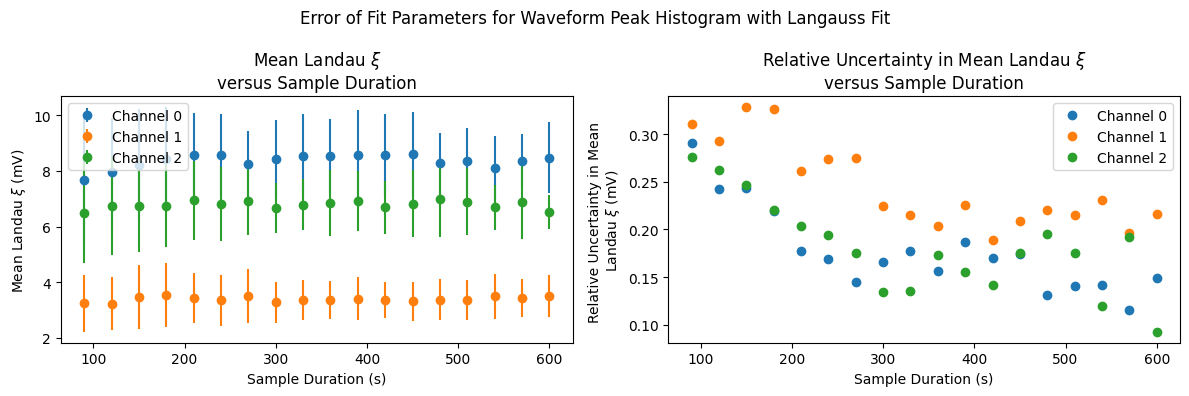

Data in subset: [26.10894518 44.19349327 30.87200785 29.46326841 41.62837885 39.62403254
 -2.01359372 33.91299249 19.79406185 19.25875903 27.80587558 29.63840687
 30.21005888 18.85373355 -2.67781946 26.95343388 34.13606847 -4.04712547
 22.55386699 28.48597014 45.96236328 27.64079363 13.11604917 50.22915029
 33.27505144 44.34455612 37.67359967 19.96724476 48.02915503 22.83515902
 26.34490791 37.10201906 38.87096924 53.0017679  68.20311497 51.56985926
 50.29169817 37.94645825 41.53449055 41.20857952 43.22314734 30.53152514
 37.3110363  50.71434069 56.13564983 31.70103026 31.75064124 34.55803716
 30.31614027 39.75926578 42.47313456 26.82853164 17.76216206 31.79197873
 51.2742293  41.17664598 26.6784278  39.61433911 36.54306622 34.62664083
 51.69058639 25.8007217  32.27954789 34.9023704  41.12219203 34.08936376
 36.82899215 34.47901665 25.59481262 84.67037094 49.46759955 33.92503025
 51.11204812 33.70362974 20.85388668 -2.73896058 47.38378516 35.80046627
 35.86797255 29.99613155 14.0112999

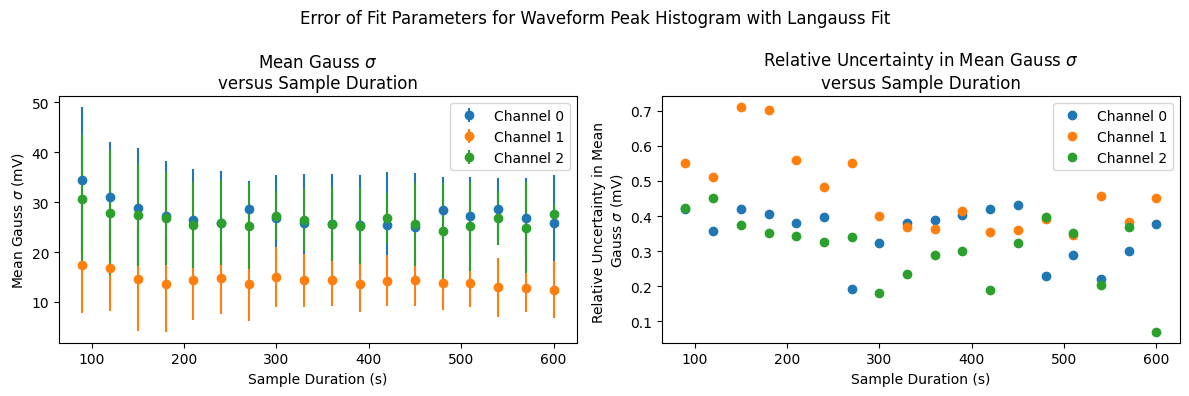

Data in subset: [70.18391308 68.57135429 50.62581043 62.15786534 72.03393928 41.36311767
 62.46957587 18.62391239 67.89485144 61.40284164 42.47930529 71.00658609
 66.2888593  42.91476619 61.05437786 25.84796128 58.822835   66.13646684
 64.91485266 38.94443967 63.68914562 66.23972172 43.68861412 70.85347221
 61.01141063 62.01423574 67.35021509 64.67140431 60.6272388  48.53337459
 37.24878026 41.44615233 62.57444725 67.80707216 71.99263361 68.94820246
 65.61798745 64.83102301 56.96520403 51.05751301 63.70399249 69.91565981
 62.31890443 67.95577819 67.1132636  69.26807055 67.06704802 52.76455117
 61.21857774 68.83322386 66.40681597 52.20015211 42.71307407 58.71361726
 65.03898991 66.01010192 53.10658015 54.49625018 65.26392429 54.55733458
 50.90339584 63.82765499 43.78642804 53.33793899 63.23951263 53.55050308
 65.40509121 37.80911924 53.19607838 62.83792733 61.21451032 24.31415075
 60.44657695 47.79842896 45.70311561 55.45169806 73.09021665 69.05621321
 64.05242918 57.67360757 60.2138328

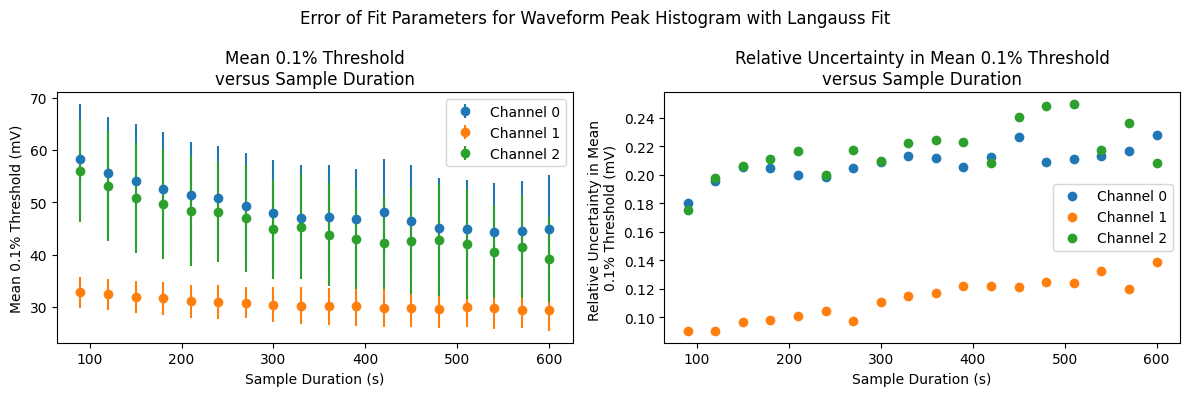

In [25]:
# def get_mean_and_std2(data, ch, idx, durations, pm = True):
#    output = []
#    for i in range(len(durations)):
#       subset = data[i][ch][idx]
#       output.append([np.mean(subset),np.std(subset)])
#    return output

def get_mean_and_std2(data, ch, idx, durations, pm=True):
   output = []
   for i in range(len(durations)):
      subset = data[i][ch][idx]
      
      # The Print Trap
      if np.std(subset) > 0.5: 
          print(f"WARNING: High STD at duration {durations[i]}, channel {ch}")
          print(f"Data in subset: {subset}\\n")

      # Looking for Outliers
      dict = {'data': subset}
      df = pd.DataFrame(dict)
      q1 = df['data'].quantile(0.25)
      q3 = df['data'].quantile(0.75)
      iqr = q3-q1
      lower_bound = q1 - 1.5 * iqr
      upper_bound = q3 + 1.5 * iqr
      outliers = df[(df['data'] < lower_bound) | (df['data'] > upper_bound)]
      if len(outliers) != 0:
         print(f"Outliers identified for {durations[i]}, channel {ch}:")
         print(outliers)
         print(f"Mean: {np.mean(subset)}")
          
      output.append([np.mean(subset), np.std(subset)])
   return output

stats = ['Chi-Squared per NDOF Statistic', 'MPV', r'Landau $\xi$', r'Gauss $\sigma$','0.1% Threshold']
units = ['', 'mV', 'mV', 'mV', 'mV']
p0_f=[1.2,-0.0004]
p0_g=[2,]

for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Waveform Peak Histogram with Langauss Fit")
   axs[1].set_title("Relative Uncertainty in Mean "+ stats[j] + "\nversus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty in Mean \n"+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(langaus_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()



In [13]:
energy_data = []
for duration in durations:
   dur_data = []
   df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])
   # if duration > 300:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets+1)])
   # else:
   #    df = pd.concat([pd.read_excel(f"variance_results/{duration}s_{i}.xlsx",sheet_name="Exponentially Modified Gaussian Energy") for i in range(0,n_sheets)])
   df = df.sort_values(by='Channel',kind='mergesort')
   grouped = [group for _, group in df.groupby('Channel')]
   i=0
   for ch in grouped:
      ch_stats = np.array([ch['Chi-Squared per NDOF Statistic'], ch['K'], ch['mean'], ch['std']])
      dur_data.append(ch_stats)
   energy_data.append(dur_data)

print(len(energy_data))
print(len(energy_data[0]))
print(len(energy_data[0][0]))
print(len(energy_data[0][0][0]))
print(energy_data[0][0][0])

18
4
4
180
[8.00875966e-01 2.03979528e+00 1.48032337e+00 4.35075381e-01
 1.11737628e+00 1.28052058e+02 7.62546179e-01 5.95423453e+00
 2.10137401e+00 2.56631584e+00 8.07537978e-01 6.07454898e-01
 6.13002417e-01 3.34812887e+02 3.24691219e+00 7.12490496e+01
 1.45732842e+00 1.06763091e+00 1.50103653e+00 6.44486099e-01
 9.00998944e-01 5.76574294e-01 6.01325455e+00 3.94234303e-01
 9.74444107e-01 8.45864000e-01 1.24212436e+00 1.64281089e+00
 6.82773205e-01 1.40960704e+00 9.71088133e-01 2.80868134e+01
 5.81135099e-01 1.45129241e+00 1.91033758e+00 8.81892191e-01
 4.03143650e-01 8.55034943e-01 8.03147628e-01 6.50086804e-01
 6.09452191e-01 1.38395956e+00 4.01160432e+00 1.01929873e+00
 1.05470507e+00 1.54517877e+00 1.25027287e+00 9.65475153e-01
 2.13943936e+00 1.29281610e+00 6.29931311e-01 1.12737579e+00
 3.18610670e+00 7.82842405e-01 1.21886572e+00 4.79117774e-01
 9.55649623e-01 1.58769531e+00 5.85969304e-01 6.05075326e-01
 2.89026989e+00 9.20699253e-01 2.43775324e+00 9.84492482e-01
 4.01345819e-

Data in subset: [8.00875966e-01 2.03979528e+00 1.48032337e+00 4.35075381e-01
 1.11737628e+00 1.28052058e+02 7.62546179e-01 5.95423453e+00
 2.10137401e+00 2.56631584e+00 8.07537978e-01 6.07454898e-01
 6.13002417e-01 3.34812887e+02 3.24691219e+00 7.12490496e+01
 1.45732842e+00 1.06763091e+00 1.50103653e+00 6.44486099e-01
 9.00998944e-01 5.76574294e-01 6.01325455e+00 3.94234303e-01
 9.74444107e-01 8.45864000e-01 1.24212436e+00 1.64281089e+00
 6.82773205e-01 1.40960704e+00 9.71088133e-01 2.80868134e+01
 5.81135099e-01 1.45129241e+00 1.91033758e+00 8.81892191e-01
 4.03143650e-01 8.55034943e-01 8.03147628e-01 6.50086804e-01
 6.09452191e-01 1.38395956e+00 4.01160432e+00 1.01929873e+00
 1.05470507e+00 1.54517877e+00 1.25027287e+00 9.65475153e-01
 2.13943936e+00 1.29281610e+00 6.29931311e-01 1.12737579e+00
 3.18610670e+00 7.82842405e-01 1.21886572e+00 4.79117774e-01
 9.55649623e-01 1.58769531e+00 5.85969304e-01 6.05075326e-01
 2.89026989e+00 9.20699253e-01 2.43775324e+00 9.84492482e-01
 4.01345

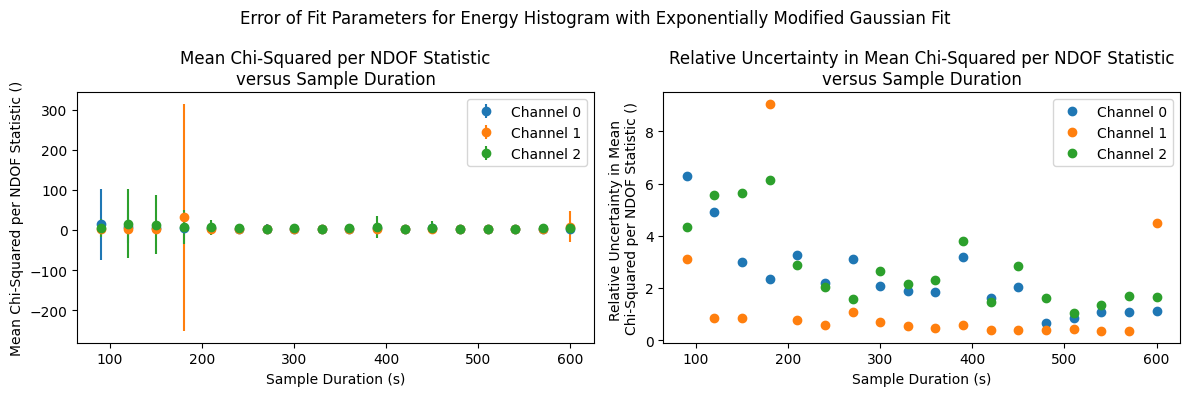

Outliers identified for 90, channel 0:
          data
31   11.613874
74    8.566097
107   9.925768
147  12.047340
Mean: 2.9014748547827987
Outliers identified for 120, channel 0:
         data
20  11.506454
44  15.034320
51  14.455938
80  10.813205
Mean: 3.1124063104772755
Outliers identified for 150, channel 0:
         data
0    7.257308
4    6.276477
30   9.159674
66   7.516372
108  6.249237
Mean: 3.0089986852102326
Outliers identified for 180, channel 0:
         data
11  11.320485
24   6.810583
45   7.753036
72   6.947721
81   6.222743
Mean: 2.987678132175217
Outliers identified for 210, channel 0:
         data
0   12.694184
21   6.793919
25  13.318098
32   6.783386
48   6.924362
51  13.631371
81   6.009736
Mean: 3.3379307641366944
Outliers identified for 240, channel 0:
        data
18  7.540550
27  9.994966
Mean: 3.028279579799205
Outliers identified for 270, channel 0:
       data
12  5.68071
32  8.63139
Mean: 2.9366733701071404
Outliers identified for 300, channel 0:
        

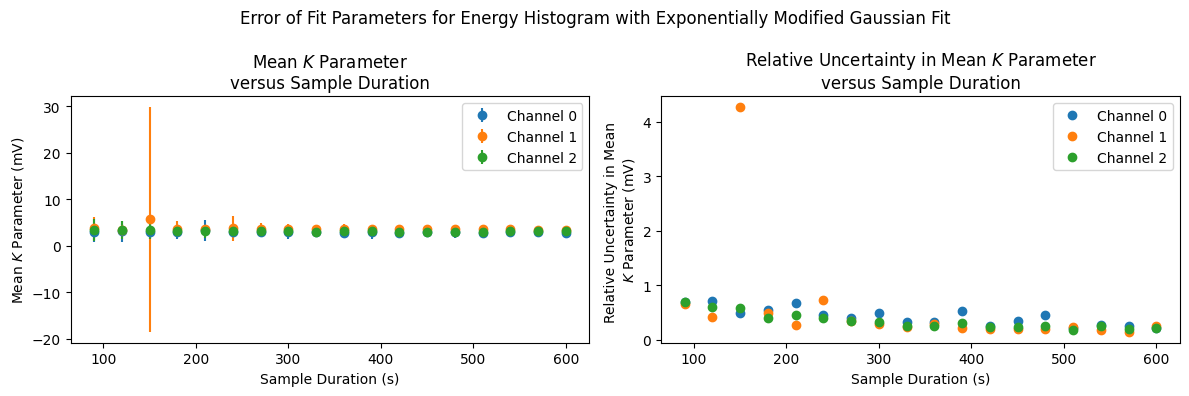

Data in subset: [1858.17064722 1832.17175095 1800.51839045 1886.8430897  2015.86907757
 1831.04166196 1960.63727544 1834.79799771 1866.81706031 1905.76878027
 2052.00556805 1941.45493477 2131.3848287  1966.98404248 1819.26225601
 1841.23800764 2470.90895254 1981.54623379 2116.18990024 2229.92038801
 2103.67250577 2013.90026942 1793.62140763 1971.27864499 1846.14000109
 1691.10154469 1905.09512397 1868.43406717 1983.0782036  1823.91750845
 2028.09121228 1850.63664641 2164.51245647 1959.79222337 1832.50653834
 1735.23394483 2030.14978063 1913.60789662 1845.32008214 1901.33616888
 1952.39975752 1966.71177845 1876.22111221 2393.87754343 1773.75760374
 1954.98473671 2007.35640776 2025.80456041 1868.9841662  1893.97602785
 1949.78356267 1838.48060635 1973.02047601 1959.77605006 1813.5897063
 1827.51340329 1858.62227628 1889.38323739 2154.30477218 2018.9676307
 1964.32554894 1963.46286831 1812.16213026 2096.64688095 2311.62503488
 1765.0292309  1713.8029787  1919.05536206 1860.59778977 1776.1

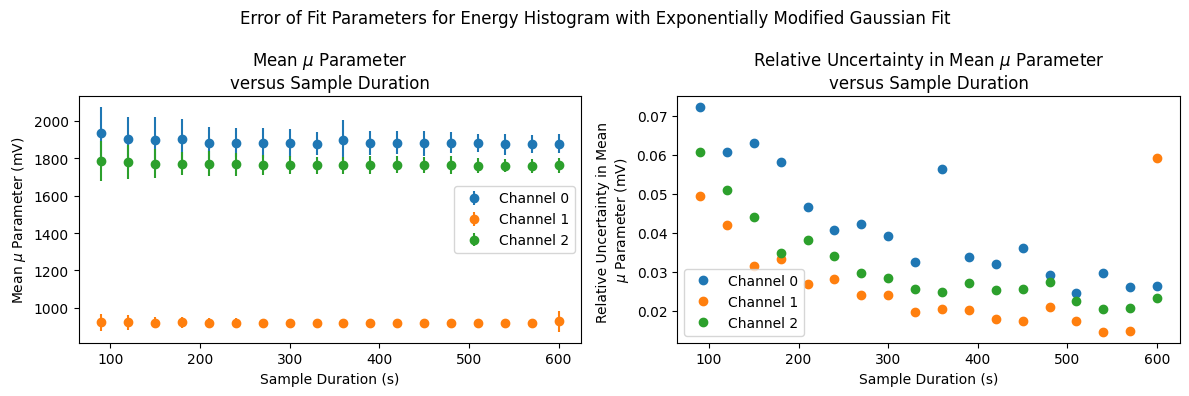

Data in subset: [296.00553019 149.98189265 238.55557317 347.45619336 646.08119424
 192.7166742  465.88017291 362.13929901 202.32563714 189.60698883
 445.10051645 302.17247258 327.75306966 221.12359408 242.25727223
 269.13161512 648.35301466 575.17493459 435.5283336  548.72018738
 628.36426138 478.61339448 225.29007029 321.53510454 295.3483393
 162.3544204  508.83945736 199.83438371 374.4307513  267.49885082
 416.21398697  94.94952797 588.48260236 314.88791985 459.93890759
 185.47889642 569.4298499  355.05811626 310.27013629 364.38481879
 371.05480946 304.12449016 173.17890291 775.17970236 167.66613208
 602.26433595 480.49922821 487.43439572 201.53080151 267.27437411
 410.87600109 244.174745   299.47292785 315.96241976 503.08445232
 330.8304771  357.57088411 309.17571897 635.78730493 337.00033164
 501.94014662 378.65136496 283.33027098 576.79774488 662.81173303
 257.75934786 164.54060486 247.95413937 389.61189842 202.45928239
 678.63530573 427.14799258 403.47638561 231.97501536 114.9825

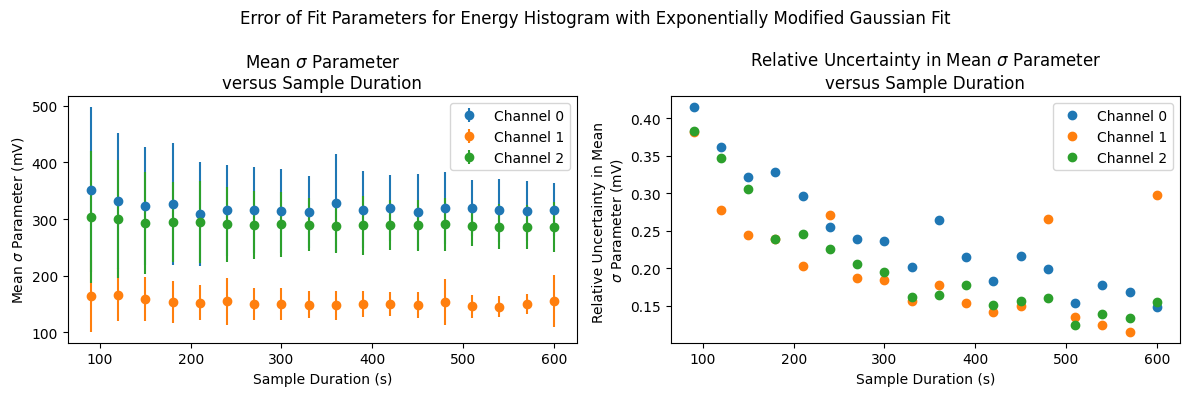

In [23]:
stats = ['Chi-Squared per NDOF Statistic', '$K$ Parameter', r'$\mu$ Parameter', r'$\sigma$ Parameter']
units = ['', 'mV', 'mV', 'mV']
for j in range(len(stats)):
   fig, axs = plt.subplots(1,2,figsize=(12,4))
   fig.suptitle("Error of Fit Parameters for Energy Histogram with Exponentially Modified Gaussian Fit")
   axs[1].set_title("Relative Uncertainty in Mean "+ stats[j] + "\nversus Sample Duration")
   axs[1].set_xlabel("Sample Duration (s)")
   axs[1].set_ylabel("Relative Uncertainty in Mean \n" + stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[1].plot(durations,[pair[1]/pair[0] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
      # prev_colour = axs[1].lines[-1].get_color()
      # popt_f,pcov_f = curve_fit(f,durations,[pair[1]/pair[0] for pair in info],p0=p0_f)
      # plt.plot(x,f(x, *popt_f),label=f"({popt_f[0]:.2e}$~t+{popt_f[1]:.2f}$",color=prev_colour)
      # popt_g,pcov_g = curve_fit(g,durations,[pair[1]/pair[0] for pair in info],p0=p0_g)
      # plt.plot(x,g(x, *popt_g),label=f"({popt_g[0]:.2f}"+r"$t)^{-0.5}$",color=prev_colour)
   axs[1].legend()

   axs[0].set_title("Mean "+ stats[j] + "\nversus Sample Duration")
   axs[0].set_xlabel("Sample Duration (s)")
   axs[0].set_ylabel("Mean "+ stats[j] + f" ({units[j]})")
   for ch in range(3):
      info = get_mean_and_std2(energy_data,ch,j,durations)
      axs[0].errorbar(durations,[pair[0] for pair in info],yerr=[pair[1] for pair in info],marker='o',linestyle='',label=f"Channel {ch}")
   axs[0].legend()
   plt.tight_layout()
   plt.show()